<a href="https://colab.research.google.com/github/dipaksavitre-don/15assiment/blob/main/session22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
data = pd.read_csv("/content/heart.csv")

In [4]:
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [7]:
# seperating targated feature
y = data['HeartDisease']

<Axes: xlabel='RestingBP', ylabel='Count'>

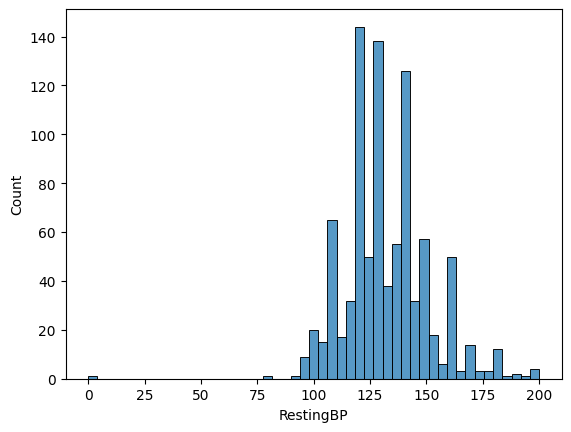

In [40]:
import seaborn as sb
sb.histplot(x=data['RestingBP'],data=data)

In [10]:
mean = data['RestingBP'].drop(0).mean()
data['RestingBP'] = data['RestingBP'].replace(0,mean)

<Axes: xlabel='Cholesterol', ylabel='Count'>

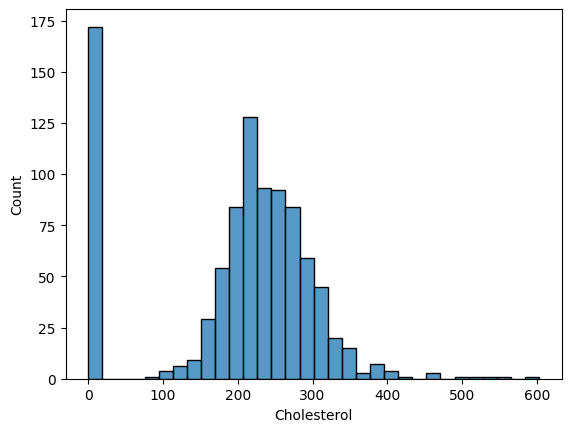

In [41]:
sb.histplot(x=data['Cholesterol'],data=data)

In [12]:
mean = data['Cholesterol'].drop(0).mean()
data['Cholesterol'] = data['Cholesterol'].replace(0,mean)

In [13]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.540728,236.028983,0.233115,136.809368,0.887364,0.553377
std,9.432617,17.989932,56.253183,0.423046,25.460334,1.066570,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,198.701200,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [14]:
# selecting the Dependent columns
x = data.drop('HeartDisease',axis=1)
x

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up
...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat


In [15]:
# performing one hot encoding on categorical columns
catcols = x.select_dtypes(include='object')


In [16]:
catcols.columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [17]:
for i in catcols.columns:
    print(x[i].unique())

['M' 'F']
['ATA' 'NAP' 'ASY' 'TA']
['Normal' 'ST' 'LVH']
['N' 'Y']
['Up' 'Flat' 'Down']


In [18]:
x = pd.get_dummies(x,columns=catcols.columns)

In [19]:
# Scaling the columns using standard scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numcols = x.select_dtypes(include='number')
x[numcols.columns] = scaler.fit_transform(x[numcols.columns])


In [20]:
numcols.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')

In [21]:
x.head(10)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414862,0.942167,-0.551341,1.382928,-0.832432,False,True,False,True,False,False,False,True,False,True,False,False,False,True
1,-0.478484,1.527201,-0.996557,-0.551341,0.754157,0.105664,True,False,False,False,True,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.141308,0.835448,-0.551341,-1.525138,-0.832432,False,True,False,True,False,False,False,False,True,True,False,False,False,True
3,-0.584556,0.303628,-0.391818,-0.551341,-1.132156,0.574711,True,False,True,False,False,False,False,True,False,False,True,False,True,False
4,0.051881,0.971031,-0.729760,-0.551341,-0.581981,-0.832432,False,True,False,False,True,False,False,True,False,True,False,False,False,True
5,-1.539213,-0.697477,1.831490,-0.551341,1.304332,-0.832432,False,True,False,False,True,False,False,True,False,True,False,False,False,True
6,-0.902775,-0.141308,0.017271,-0.551341,1.304332,-0.832432,True,False,False,True,False,False,False,True,False,True,False,False,False,True
7,0.051881,-1.253646,-0.498536,-0.551341,0.203982,-0.832432,False,True,False,True,False,False,False,True,False,True,False,False,False,True
8,-1.751359,0.414862,-0.516323,-0.551341,-0.267596,0.574711,False,True,True,False,False,False,False,True,False,False,True,False,True,False
9,-0.584556,-0.697477,0.853235,-0.551341,-0.660578,-0.832432,True,False,False,True,False,False,False,True,False,True,False,False,False,True


In [22]:
"""Q2. (Train-Test Split)
Split the preprocessed data into training and testing sets using train_test_split. Use test_size=0.20 and
random_state=42.
Print the shape of X_train, X_test, y_train, and y_test.
"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42)
print(f"Shape of x_train:{X_train.shape}")
print(f"Shape of y_train:{y_train.shape}")
print(f"Shape of x_test:{X_test.shape}")
print(f"Shape of y_test:{y_test.shape}")


Shape of x_train:(734, 20)
Shape of y_train:(734,)
Shape of x_test:(184, 20)
Shape of y_test:(184,)


In [23]:
"""Q3. (Building Logistic Regression Model)
Train a Logistic Regression model:
Import LogisticRegression from sklearn.
Create the model and fit it on the training data (X_train, y_train).
"""

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [24]:
"""Q4. (Making Predictions)
Use the trained model to predict on the test data.
Store predictions in y_pred.
Print the first 10 actual values (y_test) and predicted values (y_pred).
"""
y_pred = model.predict(X_test)


In [25]:
# comparing first 10 values of the y test and y pred
for i in range(10):
    print(f"Predicted value:{y_pred[i]}|Actual value:{y_test.iloc[i]}")

Predicted value:0|Actual value:0
Predicted value:0|Actual value:1
Predicted value:1|Actual value:1
Predicted value:1|Actual value:1
Predicted value:0|Actual value:0
Predicted value:1|Actual value:1
Predicted value:1|Actual value:1
Predicted value:0|Actual value:0
Predicted value:1|Actual value:1
Predicted value:1|Actual value:1


In [26]:
"""Q5. (Confusion Matrix)
Create a Confusion Matrix using confusion_matrix(y_test, y_pred).
Display the matrix.
Label TN, FP, FN, and TP in the output.
"""

from sklearn.metrics import confusion_matrix as c
mat = c(y_test, y_pred)
mat

array([[68,  9],
       [17, 90]])

In [27]:
print(f"TN:{mat[0][0]}")
print(f"Fp:{mat[0][1]}")
print(f"FN:{mat[1][0]}")
print(f"TP:{mat[1][1]}")

TN:68
Fp:9
FN:17
TP:90


In [28]:
"""Q6. (Model Evaluation Metrics)
Calculate the following metrics:
Accuracy
Precision
Recall
F1 Score
"""
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

accuracy = accuracy_score(y_pred,y_test)
precision = precision_score(y_pred,y_test)
recall = recall_score(y_pred,y_test)
F1_score = f1_score(y_pred,y_test)

In [29]:
print(f"accuracy:{accuracy}")
print(f"precision:{precision}")
print(f"Recall:{recall}")
print(f"F1_score:{F1_score}")

accuracy:0.8586956521739131
precision:0.8411214953271028
Recall:0.9090909090909091
F1_score:0.8737864077669902


In [31]:
columns = x.columns

In [30]:
from sklearn.metrics import classification_report as r
report = r(y_pred,y_test)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.80      0.84        85
           1       0.84      0.91      0.87        99

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



In [32]:
import joblib as jb
jb.dump(model,"heart_model.pkl")
jb.dump(scaler,"scaler.pkl")
columns = x.columns
jb.dump(columns,"columns.pkl")
print("Model is dumped!")

Model is dumped!


In [33]:
"""Q8. (Loading & Testing Saved Model)
Load the saved model and objects.
Create sample input data (one patient record).
Preprocess the input (encoding + scaling).
Make a prediction using the loaded model and print the result."""

mdl = jb.load("heart_model.pkl")
sclr = jb.load("scaler.pkl")
column = jb.load("columns.pkl")

In [34]:
p = x.head(1).copy()
p

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.43314,0.414862,0.942167,-0.551341,1.382928,-0.832432,False,True,False,True,False,False,False,True,False,True,False,False,False,True


In [35]:
# Encoding the categorical columns
catco = p.select_dtypes(include='object')
p = pd.get_dummies(p, columns=catco.columns)


In [ ]:
# Scaling the numerical columns
numco = p.select_dtypes(include='number')
p[numco.columns] = sclr.transform(p[numco.columns])
p

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-5.828074,-7.348437,-4.181363,-1.855319,-5.322014,-1.613334,False,True,False,True,False,False,False,True,False,True,False,False,False,True


In [36]:
# adding the missing columns
for fn in column:
    if fn not in p.columns:
        p[fn]=0
        print(f"Added column is:{fn}")

In [37]:
# Reorder columns to match training data
p = p.reindex(columns=column, fill_value=0)
predection = mdl.predict(p)



In [38]:
predection

array([0])